**Laboratorio de Métodos Cuantitativos Aplicados a la Gestión**

---

# **Examen Final**

*Diciembre, 2025*




---


Nombre y Apellido: Alexander Ballera

---



Número de registro: 919064

---



---

## Observaciones Importantes

- **Librerías permitidas:** NumPy, Pandas, Matplotlib, SymPy, SciPy (Librerias complementarias consulte con el profesor)
- **Formato de entrega:** Jupyter Notebook (.ipynb) con código ejecutable y comentarios
- **Evaluación:** Se calificará código funcional, interpretación económica y calidad de visualizaciones
- **Redondeo:** Usar 2 decimales para valores monetarios, 4 para tasas porcentuales

---

**Abajo de esta línea, importá/instalá todas las *libraries* que consideres relevantes para la resolución de este examen.**

In [726]:
import sympy as sp
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import numpy_financial as nf

In [727]:
# FUNCIONES ÚTILES QUE DECLARARÉ DE MANERA GLOBAL QUE PODRÉ REUTILIZAR EN LOS EJERCICIOS

# Valor máximo de los ejes de coordenadas para mejor visualización
def x_y_max (value, factor, eje):
    value = int(float(value))
    return value*factor if (eje == 'x') else (value + factor)

# Fórmula de Equivalencia
def tasa_equivalente(i_t1, t2, t1):
    return (1 + i_t1) ** (t2 / t1) - 1

# Período de recuperación descontado
def payback_desc(flujos, rate):
    acum_desc = 0
    prd = None
    inversion_inicial = abs(flujos[0])
    
    for t in range(1, len(flujos)):
        # Descontar el flujo de caja actual
        discounted_flow = flujos[t] / (1 + rate)**t
        acum_desc += discounted_flow

        # Verificar si el flujo de caja descontado acumulado es mayor o igual a la inversión inicial
        if acum_desc >= inversion_inicial:
            # Si es así, calcular el período de recuperación descontado
            remaining_investment = inversion_inicial - (acum_desc - discounted_flow)
            prd = t - 1 + (remaining_investment / discounted_flow)
            break
    
    return prd

In [728]:
# Variables globales para gráficos
figsize = (12, 6)
layout = 'constrained'

## Ejercicio 1: Análisis de DataFrames y Operaciones Vectorizadas (25 pts)

Una cadena de supermercados analiza las ventas de 3 categorías de productos (Alimentos, Bebidas, Limpieza) durante 12 semanas. A continuación se presenta el DataFrame con los datos:

**a)** Tomando la base de datos ´datos_supermercado_simulados.csv´ Importe el DataFrame y explore:
- Mostrar las primeras 5 filas
- Verificar que no haya valores nulos
- Mostrar un resumen estadístico básico
- Interprete

In [729]:
# Importo los datos desde el archivo y muestro las primeros 5 filas
df = pd.read_csv('./datos_supermercado_simulados.csv')
print(df.head())
df.head()

   semana  cant_alimentos  cant_bebidas  cant_limpieza  precio_alimentos  \
0       1             148            82             56              1287   
1       2             138            98             54              1234   
2       3             124            77             50              1243   
3       4             117            96             56              1310   
4       5             130            95             53              1230   

   precio_bebidas  precio_limpieza  costos_operativos  
0             793             1560              33161  
1             788             1529              37297  
2             869             1583              34981  
3             832             1611              33995  
4             781             1481              39413  


,semana,cant_alimentos,cant_bebidas,cant_limpieza,precio_alimentos,precio_bebidas,precio_limpieza,costos_operativos
0,1,148,82,56,1287,793,1560,33161
1,2,138,98,54,1234,788,1529,37297
2,3,124,77,50,1243,869,1583,34981
3,4,117,96,56,1310,832,1611,33995
4,5,130,95,53,1230,781,1481,39413


In [730]:
# Verifico que no hayan valores nulos
nulos = df.isnull().sum()
print("Cantidad de valores nulos por columna:\n", nulos)

valores_nulos = nulos.sum()
print(f"\nTotal de valores nulos en el DataFrame: {valores_nulos}")
print("\nNo hay valores nulos en el DataFrame.") if valores_nulos == 0 else print("\nHay valores nulos en el DataFrame.")

Cantidad de valores nulos por columna:
 semana               0
cant_alimentos       0
cant_bebidas         0
cant_limpieza        0
precio_alimentos     0
precio_bebidas       0
precio_limpieza      0
costos_operativos    0
dtype: int64

Total de valores nulos en el DataFrame: 0

No hay valores nulos en el DataFrame.


In [731]:
# Resumen Estadístico
print("\nResumen Estadístico del DataFrame:\n", df.describe())
df.describe()


Resumen Estadístico del DataFrame:
           semana  cant_alimentos  cant_bebidas  cant_limpieza  \
count  12.000000       12.000000     12.000000      12.000000   
mean    6.500000      131.916667     86.166667      53.083333   
std     3.605551       10.933338      9.552090       3.752777   
min     1.000000      117.000000     75.000000      45.000000   
25%     3.750000      123.000000     76.750000      52.250000   
50%     6.500000      131.000000     84.000000      54.500000   
75%     9.250000      139.750000     95.250000      56.000000   
max    12.000000      148.000000     98.000000      56.000000   

       precio_alimentos  precio_bebidas  precio_limpieza  costos_operativos  
count         12.000000       12.000000        12.000000          12.000000  
mean        1257.083333      822.083333      1554.916667       36364.083333  
std           41.172494       30.221781        49.024036        2335.676210  
min         1197.000000      781.000000      1481.000000       33

,semana,cant_alimentos,cant_bebidas,cant_limpieza,precio_alimentos,precio_bebidas,precio_limpieza,costos_operativos
count,12.000000,12.000000,12.000000,12.000000,12.000000,12.000000,12.000000,12.000000
mean,6.500000,131.916667,86.166667,53.083333,1257.083333,822.083333,1554.916667,36364.083333
std,3.605551,10.933338,9.552090,3.752777,41.172494,30.221781,49.024036,2335.676210
min,1.000000,117.000000,75.000000,45.000000,1197.000000,781.000000,1481.000000,33161.000000
25%,3.750000,123.000000,76.750000,52.250000,1233.000000,791.750000,1527.500000,34210.250000
50%,6.500000,131.000000,84.000000,54.500000,1247.500000,824.500000,1546.500000,36570.000000
75%,9.250000,139.750000,95.250000,56.000000,1292.750000,841.750000,1591.500000,37641.000000
max,12.000000,148.000000,98.000000,56.000000,1314.000000,869.000000,1625.000000,40629.000000


In [732]:
print("\nInformación del DataFrame:")
print(df.info())


Información del DataFrame:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12 entries, 0 to 11
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   semana             12 non-null     int64
 1   cant_alimentos     12 non-null     int64
 2   cant_bebidas       12 non-null     int64
 3   cant_limpieza      12 non-null     int64
 4   precio_alimentos   12 non-null     int64
 5   precio_bebidas     12 non-null     int64
 6   precio_limpieza    12 non-null     int64
 7   costos_operativos  12 non-null     int64
dtypes: int64(8)
memory usage: 900.0 bytes
None


In [733]:
print("""
ANÁLISIS DESCRIPTIVO EXPLORATORIO:

El DataFrame, está estructurado de la siguiente manera:
    • 12 filas y 8 columnas
    • Las 12 filas correspondiente a las 12 semanas × 8 columnas, todas numéricas enteras, según lo muestra la información
    • El DataFrame no contiene valores nulos, lo que indica que los datos están completos y no hay entradas faltantes.

Categorías de Productos:
    1. Alimentos:    promedio 132 unidades/semana (precio: $1,257)
    2. Bebidas:      promedio 86 unidades/semana (precio: $822)
    3. Limpieza:     promedio 53 unidades/semana (precio: $1,555)

Costos Operativos:
    • Promedio: $36,364 por semana
    • Rango: $33,161 - $40,629

Algunos hallazgos:
    • Alimentos es la categoría con mayor volumen (49% del total)
    • Limpieza tiene el precio unitario más alto
    • Ventas de Limpieza son las más estables (menor variación)

""")


ANÁLISIS DESCRIPTIVO EXPLORATORIO:

El DataFrame, está estructurado de la siguiente manera:
    • 12 filas y 8 columnas
    • Las 12 filas correspondiente a las 12 semanas × 8 columnas, todas numéricas enteras, según lo muestra la información
    • El DataFrame no contiene valores nulos, lo que indica que los datos están completos y no hay entradas faltantes.

Categorías de Productos:
    1. Alimentos:    promedio 132 unidades/semana (precio: $1,257)
    2. Bebidas:      promedio 86 unidades/semana (precio: $822)
    3. Limpieza:     promedio 53 unidades/semana (precio: $1,555)

Costos Operativos:
    • Promedio: $36,364 por semana
    • Rango: $33,161 - $40,629

Algunos hallazgos:
    • Alimentos es la categoría con mayor volumen (49% del total)
    • Limpieza tiene el precio unitario más alto
    • Ventas de Limpieza son las más estables (menor variación)




**b)** Crear columnas adicionales:
- `ingreso_semanal`
- `margen_bruto`
- `rentabilidad_%`

In [734]:
# b.1 Columna adicional: Ingreso semanal
df['ingreso_semanal'] = (df['cant_alimentos'] * df['precio_alimentos'] + 
                         df['cant_bebidas'] * df['precio_bebidas'] + 
                         df['cant_limpieza'] * df['precio_limpieza'])
df.head()


,semana,cant_alimentos,cant_bebidas,cant_limpieza,precio_alimentos,precio_bebidas,precio_limpieza,costos_operativos,ingreso_semanal
0,1,148,82,56,1287,793,1560,33161,342862
1,2,138,98,54,1234,788,1529,37297,330082
2,3,124,77,50,1243,869,1583,34981,300195
3,4,117,96,56,1310,832,1611,33995,323358
4,5,130,95,53,1230,781,1481,39413,312588


In [735]:
# b.2 Columna adicional: margen bruto = Ingresos - Costos
df['margen_bruto'] = df['ingreso_semanal'] - df['costos_operativos']
df.head()

,semana,cant_alimentos,cant_bebidas,cant_limpieza,precio_alimentos,precio_bebidas,precio_limpieza,costos_operativos,ingreso_semanal,margen_bruto
0,1,148,82,56,1287,793,1560,33161,342862,309701
1,2,138,98,54,1234,788,1529,37297,330082,292785
2,3,124,77,50,1243,869,1583,34981,300195,265214
3,4,117,96,56,1310,832,1611,33995,323358,289363
4,5,130,95,53,1230,781,1481,39413,312588,273175


In [736]:
# b.3 Columna adicional: rentabilidad_% = (margen_bruto / ingreso_semanal) * 100
df['rentabilidad_%'] = (df['margen_bruto'] / df['ingreso_semanal']) * 100
df.head()

,semana,cant_alimentos,cant_bebidas,cant_limpieza,precio_alimentos,precio_bebidas,precio_limpieza,costos_operativos,ingreso_semanal,margen_bruto,rentabilidad_%
0,1,148,82,56,1287,793,1560,33161,342862,309701,90.328179
1,2,138,98,54,1234,788,1529,37297,330082,292785,88.700686
2,3,124,77,50,1243,869,1583,34981,300195,265214,88.347241
3,4,117,96,56,1310,832,1611,33995,323358,289363,89.486885
4,5,130,95,53,1230,781,1481,39413,312588,273175,87.391391


**c)** Calcular:
- Ingreso total por categoría en todo el período
- Porcentaje de participación de cada categoría sobre el ingreso total
- Identificar la semana con mayor y menor rentabilidad

In [737]:
# c.1 Ingreso total por categoría en todo el período

# Calcular ingreso por categoría
ingreso_alimentos = (df['cant_alimentos'] * df['precio_alimentos']).sum()
ingreso_bebidas = (df['cant_bebidas'] * df['precio_bebidas']).sum()
ingreso_limpieza = (df['cant_limpieza'] * df['precio_limpieza']).sum()

# Ingreso total del período
ingreso_total_periodo = df['ingreso_semanal'].sum()

print(f"""INGRESO TOTAL POR CATEGORÍA (12 semanas):

Alimentos:  ${ingreso_alimentos:>12,.2f}
Bebidas:    ${ingreso_bebidas:>12,.2f}
Limpieza:   ${ingreso_limpieza:>12,.2f}

TOTAL:      ${ingreso_total_periodo:>12,.2f}
""")

INGRESO TOTAL POR CATEGORÍA (12 semanas):

Alimentos:  $1,990,665.00
Bebidas:    $  849,312.00
Limpieza:   $  990,371.00

TOTAL:      $3,830,348.00



In [738]:
# c.2 Porcentaje de participación de cada categoría sobre el ingreso total

# Calcular porcentajes de participación
participacion_alimentos = (ingreso_alimentos / ingreso_total_periodo) * 100
participacion_bebidas = (ingreso_bebidas / ingreso_total_periodo) * 100
participacion_limpieza = (ingreso_limpieza / ingreso_total_periodo) * 100

print(f"""
PARTICIPACIÓN PORCENTUAL POR CATEGORÍA:

Alimentos:  {participacion_alimentos:>6.2f}%
Bebidas:    {participacion_bebidas:>6.2f}%
Limpieza:   {participacion_limpieza:>6.2f}%

TOTAL:      {participacion_alimentos + participacion_bebidas + participacion_limpieza:>6.2f}%

Interpretación:

La categoría Alimentos representa el {participacion_alimentos:.2f}% del ingreso total,
siendo la más importante en términos de facturación. Le sigue
Limpieza con {participacion_limpieza:.2f}% y finalmente Bebidas con {participacion_bebidas:.2f}%.

""")


PARTICIPACIÓN PORCENTUAL POR CATEGORÍA:

Alimentos:   51.97%
Bebidas:     22.17%
Limpieza:    25.86%

TOTAL:      100.00%

Interpretación:

La categoría Alimentos representa el 51.97% del ingreso total,
siendo la más importante en términos de facturación. Le sigue
Limpieza con 25.86% y finalmente Bebidas con 22.17%.




**d)** Definir una función `clasificar_desempeno(df)` que agregue una columna `estado` con:
- "Excelente" si rentabilidad_% ≥ 15%
- "Bueno" si 10% ≤ rentabilidad_% < 15%
- "Regular" si rentabilidad_% < 10%

Aplicar la función al DataFrame.

In [739]:
# d) Función para clasificar el desempeño según rentabilidad
def clasificar_desempeno(df):
    condiciones = [
        df['rentabilidad_%'] >= 15,
        (df['rentabilidad_%'] >= 10) & (df['rentabilidad_%'] < 15),
        df['rentabilidad_%'] < 10
    ]
    categorias = ['Excelente', 'Bueno', 'Regular']
    df['estado'] = np.select(condiciones, categorias, default='Sin datos')
    return df

df = clasificar_desempeno(df)
df[['semana', 'rentabilidad_%', 'estado']].head()

,semana,rentabilidad_%,estado
0,1,90.328179,Excelente
1,2,88.700686,Excelente
2,3,88.347241,Excelente
3,4,89.486885,Excelente
4,5,87.391391,Excelente


In [740]:
df.head()

,semana,cant_alimentos,cant_bebidas,cant_limpieza,precio_alimentos,precio_bebidas,precio_limpieza,costos_operativos,ingreso_semanal,margen_bruto,rentabilidad_%,estado
0,1,148,82,56,1287,793,1560,33161,342862,309701,90.328179,Excelente
1,2,138,98,54,1234,788,1529,37297,330082,292785,88.700686,Excelente
2,3,124,77,50,1243,869,1583,34981,300195,265214,88.347241,Excelente
3,4,117,96,56,1310,832,1611,33995,323358,289363,89.486885,Excelente
4,5,130,95,53,1230,781,1481,39413,312588,273175,87.391391,Excelente


**e)** Crear dos gráficos:
- Gráfico de líneas: evolución del margen_bruto a lo largo de las semanas
- Gráfico de barras: participación porcentual de cada categoría en el ingreso total
- Interprete

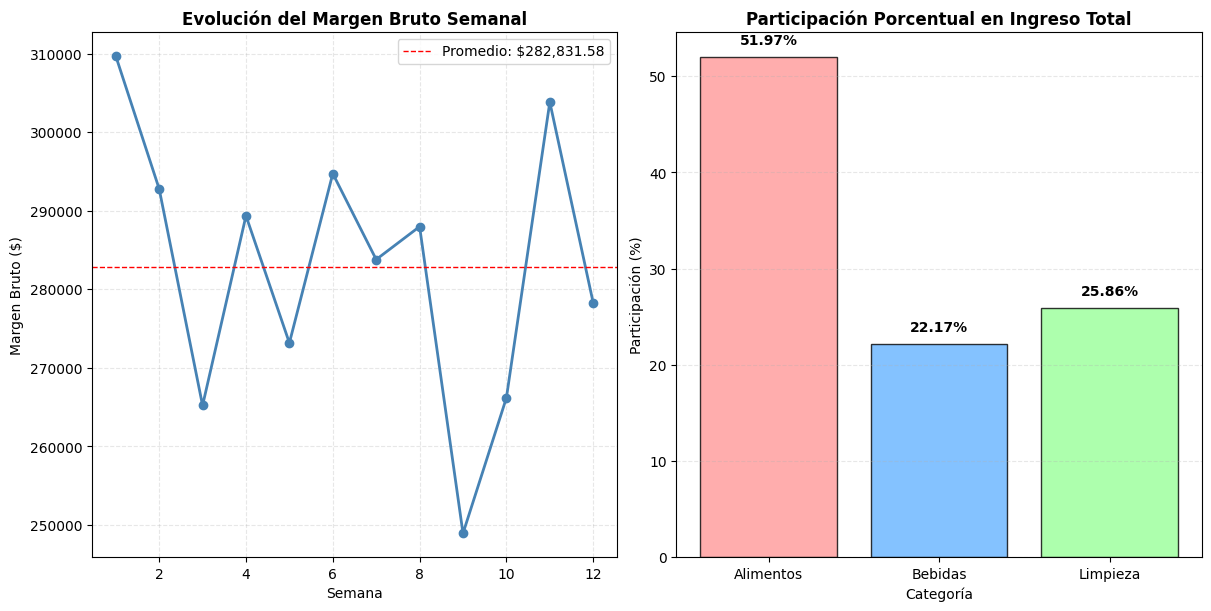


INTERPRETACIÓN DE LOS GRÁFICOS:

Gráfico 1 - Evolución del Margen Bruto:
• El margen bruto muestra fluctuaciones semanales entre $248,933.00 y $309,701.00
• Promedio semanal: $282,831.58
• La línea roja indica el margen promedio
• Se observa una tendencia decreciente del periodo, con mucha volatilidad

Gráfico 2 - Participación por Categoría:
• Alimentos domina con 51.97% del ingreso total
• Limpieza aporta 25.86% (segundo lugar)
• Bebidas representa 22.17% del ingreso

Conclusión:
Se recomienda que la estrategia comercial se enfoque en la categoría Alimentos ya que es la
que más aporta al ingreso total, mientras se buscan oportunidades de crecimiento en Bebidas y se mantiene
el posicionamiento en productos de Limpieza.



In [741]:
# Gráficos
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=figsize, layout=layout)

# Gráfico 1: Evolución del margen bruto a lo largo de las semanas
ax1.plot(df['semana'], df['margen_bruto'], marker='o', linewidth=2, color='steelblue', markersize=6)
ax1.set_title('Evolución del Margen Bruto Semanal', fontsize=12, fontweight='bold')
ax1.set_xlabel('Semana', fontsize=10)
ax1.set_ylabel('Margen Bruto ($)', fontsize=10)
ax1.grid(True, alpha=0.3, linestyle='--')
ax1.axhline(df['margen_bruto'].mean(), color='red', linestyle='--', linewidth=1, 
            label=f"Promedio: ${df['margen_bruto'].mean():,.2f}")
ax1.legend(loc='best')

# Gráfico 2: Participación porcentual por categoría
categorias = ['Alimentos', 'Bebidas', 'Limpieza']
participaciones = [participacion_alimentos, participacion_bebidas, participacion_limpieza]
colores = ['#ff9999', '#66b3ff', '#99ff99']

ax2.bar(categorias, participaciones, color=colores, alpha=0.8, edgecolor='black')
ax2.set_title('Participación Porcentual en Ingreso Total', fontsize=12, fontweight='bold')
ax2.set_xlabel('Categoría', fontsize=10)
ax2.set_ylabel('Participación (%)', fontsize=10)
ax2.grid(True, alpha=0.3, linestyle='--', axis='y')

# Agregar valores sobre las barras
for i, (cat, val) in enumerate(zip(categorias, participaciones)):
    ax2.text(i, val + 1, f'{val:.2f}%', ha='center', va='bottom', fontweight='bold')

plt.show()

# Interpretación
print(f"""
INTERPRETACIÓN DE LOS GRÁFICOS:

Gráfico 1 - Evolución del Margen Bruto:
• El margen bruto muestra fluctuaciones semanales entre ${df['margen_bruto'].min():,.2f} y ${df['margen_bruto'].max():,.2f}
• Promedio semanal: ${df['margen_bruto'].mean():,.2f}
• La línea roja indica el margen promedio
• Se observa una tendencia decreciente del periodo, con mucha volatilidad

Gráfico 2 - Participación por Categoría:
• Alimentos domina con {participacion_alimentos:.2f}% del ingreso total
• Limpieza aporta {participacion_limpieza:.2f}% (segundo lugar)
• Bebidas representa {participacion_bebidas:.2f}% del ingreso

Conclusión:
Se recomienda que la estrategia comercial se enfoque en la categoría Alimentos ya que es la
que más aporta al ingreso total, mientras se buscan oportunidades de crecimiento en Bebidas y se mantiene
el posicionamiento en productos de Limpieza.
""")

---

## Ejercicio 2: Optimización con Derivadas (25 pts)

Una empresa tecnológica enfrenta las siguientes funciones económicas:

- **Demanda inversa:** $p(q) = 250 - 1.2q - 0.02q^2$
- **Costo Total:** $C(q) = 800 + 10q + 0.08q^2$

**a)** Definir simbólicamente (con SymPy):
- Función de Ingreso Total: $I(q)$
- Función de Beneficio Total: $B(q)$
- Función de Costo Medio: $C_{me}(q)$

In [742]:
# PASO 1: Defino funciones

# 1.1 Declarar variables simbólicas
q = sp.symbols('q', positive=True, real=True)

In [743]:
# 1.2 Función de demanda (inversa): p = f(x)
# De la ecuación: x - 90 + 2p = 0  →  p = (90 - x)/2
p = 250.0 - 1.2*q - 0.02*q**2
print("Función de Demanda (precio):")
print(f"p(q) = {p}")
p

Función de Demanda (precio):
p(q) = -0.02*q**2 - 1.2*q + 250.0


-0.02*q**2 - 1.2*q + 250.0

In [744]:
# 1.3 Función de Costo Total
C = 800 + 10*q + 0.08*q**2
print("Función de Costo Total:")
print(f"C(q) = {C}")
C

Función de Costo Total:
C(q) = 0.08*q**2 + 10*q + 800


0.08*q**2 + 10*q + 800

In [745]:
# 1.4 Función de Costo Medio: Cme = CT / x
CMe = sp.simplify(C / q)
print("Función de Costo Medio:")
print(f"CMe(x) = {CMe}")
CMe


Función de Costo Medio:
CMe(x) = 0.08*q + 10 + 800/q


0.08*q + 10 + 800/q

In [746]:
# 1.5 Función de Ingreso Total: IT = p * x
I = sp.simplify(p * q)
print("Función de Ingreso Total:")
print(f"I(q) = {I}")
I

Función de Ingreso Total:
I(q) = q*(-0.02*q**2 - 1.2*q + 250.0)


q*(-0.02*q**2 - 1.2*q + 250.0)

In [747]:
# 1.6 Función de Beneficio: B = I - C
B = sp.simplify(I - C)
print("Función de Beneficio:")
print(f"B(q) = {B}")
B

Función de Beneficio:
B(q) = -0.02*q**3 - 1.28*q**2 + 240.0*q - 800.0


-0.02*q**3 - 1.28*q**2 + 240.0*q - 800.0

**b)** Calcule:
- Ingreso Marginal: $I'(q)$
- Costo Marginal: $C'(q)$
- Derivada del Beneficio: $B'(q)$

In [748]:
# b.1 Ingreso Marginal
dI_dq = sp.diff(I, q)
print("Ingreso Marginal:")
print(f"dI_dq'(q) = {dI_dq}")
dI_dq

Ingreso Marginal:
dI_dq'(q) = -0.02*q**2 + q*(-0.04*q - 1.2) - 1.2*q + 250.0


-0.02*q**2 + q*(-0.04*q - 1.2) - 1.2*q + 250.0

In [749]:
# b.2 Costo Marginal
dC_dx = sp.diff(C, q)
print("Costo Marginal:")
print(f"dC_dx(x) = {dC_dx}")
dC_dx

Costo Marginal:
dC_dx(x) = 0.16*q + 10


0.16*q + 10

In [750]:
# b.3 Beneficio Marginal
dB_dq = sp.diff(B, q)
print("Derivada del Beneficio:")
print(f"dB_dq(q) = {dB_dq}")
dB_dq

Derivada del Beneficio:
dB_dq(q) = -0.06*q**2 - 2.56*q + 240.0


-0.06*q**2 - 2.56*q + 240.0

**c)** Optimización:
- Hallar la cantidad que maximiza el beneficio
- Verificar con la segunda derivada que es un máximo
- Hallar precio óptimo e ingreso total óptimo

In [751]:
# c.1 Encontrar puntos críticos (donde B'(x) = 0)
puntos_criticos = sp.solve(dB_dq, q)
print("Puntos Críticos (B'(q) = 0):")
puntos_criticos

Puntos Críticos (B'(q) = 0):


[45.4132853908471]

In [752]:
# c.2 Calcular segunda derivada para verificar máximo
d2B_dq2 = sp.diff(dB_dq, q)
print("Segunda Derivada del Beneficio:")
print(f"d2B_dq2(q) = {d2B_dq2}")
d2B_dq2

Segunda Derivada del Beneficio:
d2B_dq2(q) = -0.12*q - 2.56


-0.12*q - 2.56

In [753]:
segunda_deriv = float(d2B_dq2.subs(q, puntos_criticos[0]))

print(f'Con la segunda derivada se verifica que el punto crítico es un punto {"MÁXIMO" if segunda_deriv < 0 else "MÍNIMO"}')

Con la segunda derivada se verifica que el punto crítico es un punto MÁXIMO


In [754]:
beneficio = float(B.subs(q, puntos_criticos[0]))
# precio = float(p.subs(q, puntos_criticos[0]))
costo = float(C.subs(q, puntos_criticos[0]))
ingreso = float(I.subs(q, puntos_criticos[0]))
        
print("SOLUCIÓN ÓPTIMA")
print("="*70)
print(f"NIVEL DE PRODUCCIÓN ÓPTIMO:")
print(f"   x* = {puntos_criticos[0]:.2f} unidades")
print(f"\n RESULTADOS ECONÓMICOS:")
# print(f"   Precio óptimo: ${precio:.2f}")
print(f"   Beneficio máximo: ${beneficio:.2f}")
print(f"   Ingreso total: ${ingreso:.2f}")
print(f"   Costo total: ${costo:.2f}")

SOLUCIÓN ÓPTIMA
NIVEL DE PRODUCCIÓN ÓPTIMO:
   x* = 45.41 unidades

 RESULTADOS ECONÓMICOS:
   Beneficio máximo: $5586.18
   Ingreso total: $7005.30
   Costo total: $1419.12


**d)** Elasticidad precio de la demanda:
- Obtener la expresión general: $\varepsilon = \frac{dQ}{dp} \cdot \frac{p}{Q}$
- Evaluar la elasticidad en $q = 50$ y clasificarla (elástica/inelástica/unitaria)

---

## Ejercicio 3: Integración y Excedentes Económicos (25 pts)

En un mercado se presentan las siguientes funciones:

- **Demanda:** $p_d(q) = 100 - 3q - 0.7q^2$
- **Oferta:** $p_s(q) = 25 + 1.8q$

**a)** Encontrar el equilibrio de mercado:
- Resolver $p_d(q) = p_s(q)$ para obtener $q^*$
- Calcular el precio de equilibrio $p^*$
- Verificar numéricamente el resultado

In [755]:
# Planteo y validación
# Las funciones de oferta y demanda ya se encuentran planteadas como funciones inversas
# de precio en función de cantidad. Por lo tanto, no es necesario realizar modificaciones
# adicionales como funciones inversas.

In [756]:
# Paso 1 Defino las variables simbólicas
p, q = sp.symbols('p q', real=True, positive=True)
p, q

(p, q)

In [757]:
# Paso 2 Defino la función de oferta 
P_s = 25.0 + 1.8*q
P_s

1.8*q + 25.0

In [758]:
# Paso 3 Defino la función de demanda
P_d = 100.0 - 3*q - 0.7*q**2
P_d

-0.7*q**2 - 3*q + 100.0

In [759]:
# Paso 4 Encuentro cantidad óptima q* de equilibrio de mercado P_s(q) = P_d(q)
q_eq = sp.Eq(P_d, P_s)
q_eq = sp.solve(q_eq, q)
q_eq = q_eq[0]
q_eq

7.47546264986365

In [760]:
# Paso 5 Encuentro precio de equilibrio
p_eq = P_s.subs(q, q_eq)
p_eq

38.4558327697546

In [761]:
print("EQUILIBRIO DEL MERCADO:")
print(f"""
Ecuación: P_d = P_s
q* = {q_eq}
p* = {p_eq:.2f}

Validación Numérica:
P_s(q*) = {P_s.subs(q, q_eq):.2f}
P_d(q*) = {P_d.subs(q, q_eq):.2f}

¿Son iguales? {sp.simplify(P_s.subs(q, q_eq) - P_d.subs(q, q_eq)) == 0}
""")

EQUILIBRIO DEL MERCADO:

Ecuación: P_d = P_s
q* = 7.47546264986365
p* = 38.46

Validación Numérica:
P_s(q*) = 38.46
P_d(q*) = 38.46

¿Son iguales? True



**b)** Calcular el Excedente del Consumidor (EC):
- Definir la integral: $EC = \int_0^{q^*} [p_d(q) - p^*] \, dq$
- Resolver simbólicamente con SymPy
- Evaluar numéricamente

In [762]:
print("INTERPRETACIÓN:")
print("  • EC mide el área entre la curva de demanda y el precio de equilibrio")
print("  • EP mide el área entre el precio de equilibrio y la curva de oferta")
print()
print("OBJETIVOS:")
print(f"  • EC = ∫[0, {q_eq}] [P_d(q) - {p_eq:.2f}] dq")
print(f"  • EP = ∫[0, {q_eq}] [{p_eq:.2f} - P_s(q)] dq")

INTERPRETACIÓN:
  • EC mide el área entre la curva de demanda y el precio de equilibrio
  • EP mide el área entre el precio de equilibrio y la curva de oferta

OBJETIVOS:
  • EC = ∫[0, 7.47546264986365] [P_d(q) - 38.46] dq
  • EP = ∫[0, 7.47546264986365] [38.46 - P_s(q)] dq


In [763]:
# Excedente del Consumidor (EC)
EC = sp.integrate(P_d - p_eq, (q, 0, q_eq))

print('''
EC: Es el beneficio que obtienen los consumidores por pagar un precio menor
al que estaban dispuestos a pagar.
''')
print(f"EC = {EC:.2f}")


EC: Es el beneficio que obtienen los consumidores por pagar un precio menor
al que estaban dispuestos a pagar.

EC = 278.77


**c)** Calcular el Excedente del Productor (EP):
- Definir la integral: $EP = \int_0^{q^*} [p^* - p_s(q)] \, dq$
- Resolver simbólicamente
- Evaluar numéricamente

In [764]:
# Excedente del Productor (EP)
EP = sp.integrate(p_eq - P_s, (q,0, q_eq))

print('''
EP: Es el beneficio que obtienen los productores por vender a un precio mayor
al que estaban dispuestos a vender.
''')
print(f"EP = {EP:.2f}")


EP: Es el beneficio que obtienen los productores por vender a un precio mayor
al que estaban dispuestos a vender.

EP = 50.29


**d)** Calcular el Bienestar Social Total e interpretar el significado economico

In [765]:
# Excedente Total (ET)
ET = EC + EP # type: ignore

print('''
ET: Es la suma del beneficio que obtienen los consumidores y los productores,
representando el bienestar total generado por el mercado.
''')
print(f"ET = EC + EP = {ET:.2f}")


ET: Es la suma del beneficio que obtienen los consumidores y los productores,
representando el bienestar total generado por el mercado.

ET = EC + EP = 329.07


**e)** Grafique lo expuesto con anterioriedad e interprete

In [766]:
# Paso 1 Preparo los datos para graficar

# Valor máximo en el eje x para mejor visualización
x_max = int(float(q_eq)) # type: ignore
x_max = x_y_max (x_max, 1.5, 'x') # La función la declaré al inicio del notebook

# Valor máximo en el eje y para mejor visualización
y_max = int(float(P_d.subs(q, 0)))
y_max = x_y_max (y_max, 10, 'y') # La función la declaré al inicio del notebook

q_grid = np.linspace(0, x_max, 500)


In [767]:
P_d_num = sp.lambdify(q, P_d, 'numpy')
P_s_num = sp.lambdify(q, P_s, 'numpy')

P_d_vals = P_d_num(q_grid)
P_s_vals = P_s_num(q_grid)


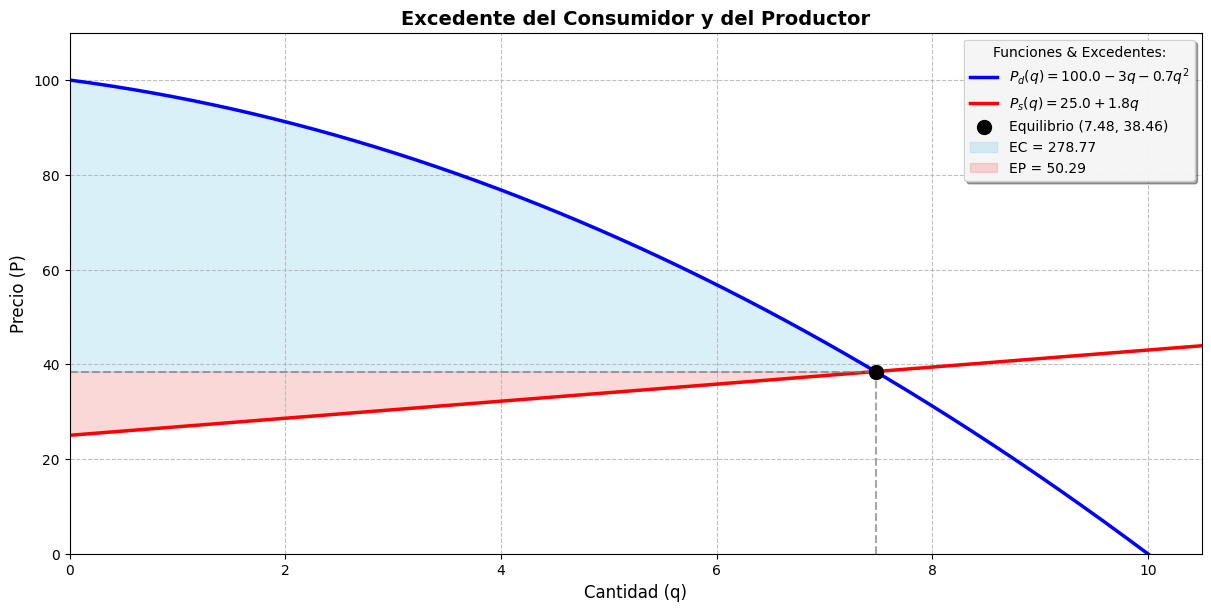

In [768]:
# Creo Gráfico
plt.figure(figsize=figsize, layout=layout)
plt.plot(q_grid, P_d_vals, label='$P_d(q) = 100.0 - 3q - 0.7q^2$', linewidth=2.5, color='blue')
plt.plot(q_grid, P_s_vals, label='$P_s(q) = 25.0 + 1.8q$', linewidth=2.5, color='red')

# Punto de equilibrio
plt.scatter([q_eq], [p_eq], s=100, c='black', zorder=5, label=f'Equilibrio ({float(q_eq):.2f}, {float(p_eq):.2f})') # type: ignore
plt.vlines(q_eq, 0, p_eq, linestyles='--', color='gray', alpha=0.7) # type: ignore
plt.hlines(p_eq, 0, q_eq, linestyles='--', color='gray', alpha=0.7) # type: ignore

# Sombrear excedentes
condicion = (q_grid <= float(q_eq)).tolist()
plt.fill_between(q_grid, P_d_vals, float(p_eq), where=condicion, 
                 alpha=0.3, color='skyblue', label=f'EC = {float(EC):.2f}') # type: ignore
plt.fill_between(q_grid, float(p_eq), P_s_vals, where=condicion, 
                 alpha=0.3, color='lightcoral', label=f'EP = {float(EP):.2f}') # type: ignore

plt.title('Excedente del Consumidor y del Productor', fontsize=14, fontweight='bold')
plt.xlabel('Cantidad (q)', fontsize=12)
plt.ylabel('Precio (P)', fontsize=12)
plt.legend(
    loc='best',
    shadow=True,
    fancybox=True,
    framealpha=0.9,
    title='Funciones & Excedentes:',
    )
plt.grid(True, alpha=0.8, linestyle='--')
plt.xlim(0, x_max)
plt.ylim(0, y_max)
plt.show()

In [769]:
print(f'''
Interpretación:

Excedente del Consumidor (EC = {EC:.2f}): Representa el beneficio neto que obtienen los consumidores al comprar
el bien a un precio de equilibrio de ${p_eq:.2f}, en lugar del precio máximo que estarían dispuestos a pagar según
la curva de demanda $P_d(q) = 100.0 - 3q - 0.7*q^2$. Este ahorro de ${EC:.2f} refleja la diferencia entre la
valoración subjetiva del bien y el precio de mercado.

Excedente del Productor (EP = {EP:.2f}): Refleja el beneficio adicional que reciben los productores al vender a
${p_eq:.2f} por unidad, superando el precio mínimo que aceptarían según su curva de oferta $P_s(q) = 20 + 3q$.
Este excedente de ${EP:.2f} representa la ganancia por encima de sus costos marginales de producción.

Excedente Total (ET = {ET:.2f}): La suma de ambos excedentes (${EC:.2f} + ${EP:.2f} = ${ET:.2f}) mide el
bienestar social total generado por el mercado cuando opera en equilibrio. Este valor representa la eficiencia
económica alcanzada cuando se intercambian {q_eq:.2f} unidades al precio de ${p_eq:.2f}.

Conclusión:

El análisis muestra que el excedente del consumidor es aproximadamente {EC/EP:.2f} veces mayor que el excedente
del productor y la proporción del EC es del {EC/ET*100:.1f}%, mientras que el EP representa solo el {EP/ET*100:.1f}% del excedente
total, con lo que podemos concluir que el mayor beneficio es capturado por los consumidores.

''')



Interpretación:

Excedente del Consumidor (EC = 278.77): Representa el beneficio neto que obtienen los consumidores al comprar
el bien a un precio de equilibrio de $38.46, en lugar del precio máximo que estarían dispuestos a pagar según
la curva de demanda $P_d(q) = 100.0 - 3q - 0.7*q^2$. Este ahorro de $278.77 refleja la diferencia entre la
valoración subjetiva del bien y el precio de mercado.

Excedente del Productor (EP = 50.29): Refleja el beneficio adicional que reciben los productores al vender a
$38.46 por unidad, superando el precio mínimo que aceptarían según su curva de oferta $P_s(q) = 20 + 3q$.
Este excedente de $50.29 representa la ganancia por encima de sus costos marginales de producción.

Excedente Total (ET = 329.07): La suma de ambos excedentes ($278.77 + $50.29 = $329.07) mide el
bienestar social total generado por el mercado cuando opera en equilibrio. Este valor representa la eficiencia
económica alcanzada cuando se intercambian 7.48 unidades al precio de $38.46.


---

## Ejercicio 4: Análisis de Inversiones (VAN, TIR, TIRM) (25 pts)

Una empresa evalúa un proyecto de expansión con el siguiente flujo de fondos **MENSUAL**.

El costo de capital anual es del **12%**.

In [770]:
inversion_inicial = -85000

cash_flows = [
    14000, -9000, 17000, 20000, -11000, 23000, 26000, 29000, -14000, 32000,
    15000, -10000, 18000, 21000, 22000, -15000, 25000, 28000, 31000, -13000,
    16000, 21000, 24000, -12000, 27000, 30000, 33000, -16000, 34000, 36000
]

flujo_total = [inversion_inicial] + cash_flows
nuevo_cash_flow = flujo_total


In [771]:
# Tasa de descuento anual
TEA = 0.1200  # 12% anual

r = tasa_equivalente(TEA, 30, 365) # La fórmula está al inicio de esta notebook
print(f"Tasa efectiva mensual equivalente: TEA {TEA:.4%} → TEM {r:.4%}")

Tasa efectiva mensual equivalente: TEA 12.0000% → TEM 0.9358%


**a)** Calcular las métricas financieras básicas:
- Valor Actual Neto (VAN)
- Tasa Interna de Retorno (TIR)
- Tasa Interna de Retorno Modificada (TIRM) con tasa de reinversión = tasa de descuento
- Interpretar cada métrica

In [772]:
# VAN
van = nf.npv(r, nuevo_cash_flow)
print(f"Tasa de descuento mensual utilizada: {r:.4%}")
print(f"""
El proyecto genera un valor actual neto de ${van:,.2f}.

El VAN es mayor que cero (VAN>0). Esto implica que el proyecto creará valor para la empresa,
ya que el valor presente de todos los flujos de caja futuros supera la inversión inicial.
Segun el VAN el proyecto es rentable
""")

Tasa de descuento mensual utilizada: 0.9358%

El proyecto genera un valor actual neto de $291,515.96.

El VAN es mayor que cero (VAN>0). Esto implica que el proyecto creará valor para la empresa,
ya que el valor presente de todos los flujos de caja futuros supera la inversión inicial.
Segun el VAN el proyecto es rentable



In [773]:
# TIR
tir = nf.irr(values=nuevo_cash_flow)

tir_anual = tasa_equivalente(tir, 365, 30) 

print(f"TEM: {r:.4%}")
print(f"TIR mensual: {tir:.4%}")
print(f"TIR anual: {tir_anual:.4%}")
print(f'\nVIABLE: La TIR ({tir_anual:.4%}) supera el costo de capital ({TEA:.4%}).')
print('''
La TIR anualizada es mayor que r. Esto implica que el proyecto creará valor para
la empresa, ya que el valor implícito del proyecto según sus cash flows supera al
costo de capital exigido al proyecto. Segun la TIR comparándola con el costo de
capital se recomienda invertir en el proyecto.
      ''')

TEM: 0.9358%
TIR mensual: 13.4767%
TIR anual: 365.6197%

VIABLE: La TIR (365.6197%) supera el costo de capital (12.0000%).

La TIR anualizada es mayor que r. Esto implica que el proyecto creará valor para
la empresa, ya que el valor implícito del proyecto según sus cash flows supera al
costo de capital exigido al proyecto. Segun la TIR comparándola con el costo de
capital se recomienda invertir en el proyecto.
      


In [774]:
# TIRM
# finance_rate: costo de financiar flujos negativos (costo de capital) - USAR TIR
# reinvest_rate: tasa de reinversión de flujos positivos (costo de oportunidad) - USAR r

tirm = nf.mirr(values=nuevo_cash_flow, finance_rate=tir, reinvest_rate=r)

tirm_anual = tasa_equivalente(tirm, 365, 30)

print(f"TIRM mensual: {tirm:.4%}")
print(f"TEM: {r:.4%}")
print(f"TIRM anual: {tirm_anual:.4%}")

print(f"\nInterpretación: La rentabilidad modificada es {tirm_anual:.4%} anual.")
print("Es más conservadora que la TIR porque asume reinversión al costo de capital.")
print(f'VIABLE: La TIRM ({tirm_anual:.4%}) supera el costo de capital ({TEA:.4%}).')
print('''
La TIRM es mayor que r. Esto implica que el proyecto creará valor para la empresa,
Ya que el valor implícito del proyecto según sus cash flows supera al costo de
capital exigido al proyecto. Segun la TIR comparándola con el costo de capital se
recomienda invertir en el proyecto.
      ''')

TIRM mensual: 5.9374%
TEM: 0.9358%
TIRM anual: 101.7283%

Interpretación: La rentabilidad modificada es 101.7283% anual.
Es más conservadora que la TIR porque asume reinversión al costo de capital.
VIABLE: La TIRM (101.7283%) supera el costo de capital (12.0000%).

La TIRM es mayor que r. Esto implica que el proyecto creará valor para la empresa,
Ya que el valor implícito del proyecto según sus cash flows supera al costo de
capital exigido al proyecto. Segun la TIR comparándola con el costo de capital se
recomienda invertir en el proyecto.
      


**b)** Calcular el Período de Recuperación Descontado (PRD) e interprete


In [775]:
# Período de Recuperación Descontado (PRD)

prd = payback_desc(nuevo_cash_flow, r) # La fórmula está al inicio de esta notebook
print(f"Payback descontado: {prd:.2f} meses ({prd/12:.2f} años)" if prd is not None else "Payback descontado: No se recupera la inversión")

print(f'''
Interpretación del Período de Recuperación Descontado (PRD):

El PRD indica que la inversión inicial de ${-inversion_inicial} se recupera en {prd:.2f} meses
cuando se consideran los flujos de caja descontados a la tasa mensual del {r*100:.4f}%.

Análisis:

- Tiempo de recuperación: {prd:.2f} meses (aproximadamente {round(prd)} meses)
- Interpretación: Un PRD corto ({round(prd)} meses) indica bajo riesgo en el corto plazo,
                  ya que la inversión se recupera rápidamente, reduciendo la
                  exposición a incertidumbres futuras, sobre todo en entornos 
                  económicos de alta volatilidad.

Conclusión:

La empresa recupera su inversión inicial en menos de {prd:.2f} meses, lo que confirma que
el proyecto es factible desde la perspectiva de liquidez y rentabilidad en el corto plazo.
      ''')

Payback descontado: 7.32 meses (0.61 años)

Interpretación del Período de Recuperación Descontado (PRD):

El PRD indica que la inversión inicial de $85000 se recupera en 7.32 meses
cuando se consideran los flujos de caja descontados a la tasa mensual del 0.9358%.

Análisis:

- Tiempo de recuperación: 7.32 meses (aproximadamente 7 meses)
- Interpretación: Un PRD corto (7 meses) indica bajo riesgo en el corto plazo,
                  ya que la inversión se recupera rápidamente, reduciendo la
                  exposición a incertidumbres futuras, sobre todo en entornos 
                  económicos de alta volatilidad.

Conclusión:

La empresa recupera su inversión inicial en menos de 7.32 meses, lo que confirma que
el proyecto es factible desde la perspectiva de liquidez y rentabilidad en el corto plazo.
      


**c)** Análisis de sensibilidad:
- Graficar el VAN vs. diferentes tasas de descuento
- Marcar en el gráfico la TIR (donde VAN = 0)
- Marcar la tasa de descuento actual (12%)
- Interpretar el comportamiento de la curva

Tasa Interna de Retorno (TIR): 13.4767%
Tasa De Descuento (r): 0.9358%


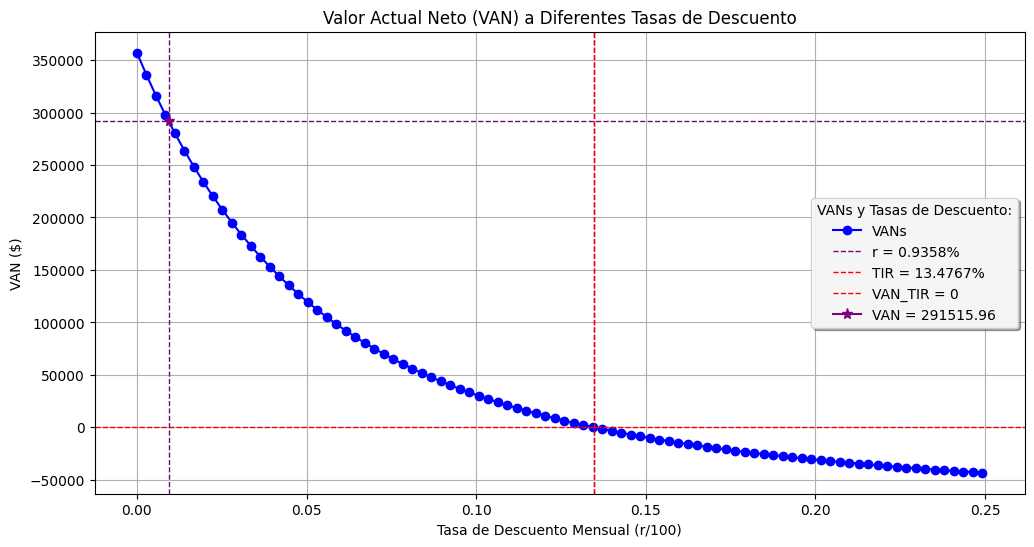

In [776]:
# Calcular TIR y TIRM
flujos = nuevo_cash_flow.copy()
van_tirm = nf.npv(tirm, nuevo_cash_flow)

print(f"Tasa Interna de Retorno (TIR): {tir:.4%}")
print(f"Tasa De Descuento (r): {r:.4%}")

# --- Crear rango de tasas para VAN ---
tasas_descuento = np.arange(0, max(tir*1.2, 0.25), 0.0028) # es muy importante agregar el max porque sino el grafico no encuentra el corte con la tir, queda desescalado.
# --- Calcular VAN para cada tasa ---
van_por_tasa = [nf.npv(tasa, flujos) for tasa in tasas_descuento]

# --- Graficar VAN vs Tasa ---
plt.figure(figsize=(12, 6))
plt.plot(tasas_descuento, van_por_tasa, marker='o', linestyle='-', color='blue', label='VANs')

# Marcar TIR y TIRM en el gráfico
plt.axvline(tir, color='purple', linestyle='--', linewidth=1, label=f"r = {r:.4%}")
plt.axvline(tir, color='red', linestyle='--', linewidth=1, label=f"TIR = {tir:.4%}")
plt.axhline(0, color='red', linestyle='--', linewidth=1, label="VAN_TIR = 0")
# plt.axvline(tirm, color='green', linestyle='--', linewidth=1, label=f"TIRM = {tirm:.2%}")
# plt.axhline(van_tirm, color='green', linestyle='--', linewidth=1, label=f"VAN_TIRM = {van_tirm:.2f}")

# grafico el punto del VAN del proyecto
plt.plot(r, van, marker='*', color='purple', markersize=8, label=f"VAN = {van:.2f}")
plt.axvline(r, color='purple', linestyle='--', linewidth=1)
plt.axhline(van, color='purple', linestyle='--', linewidth=1)

# --- Etiquetas y formato ---
plt.title('Valor Actual Neto (VAN) a Diferentes Tasas de Descuento')
plt.xlabel('Tasa de Descuento Mensual (r/100)')
plt.ylabel('VAN ($)')
plt.grid(True)
plt.legend(
    loc='best',
    shadow=True,
    fancybox=True,
    framealpha=0.9,
    title='VANs y Tasas de Descuento:',
    )
plt.show()

In [777]:
print(f'''
Análisis del Gráfico VANs vs Tasas de Descuento:**

El gráfico muestra la relación inversa entre el VAN y la tasa de descuento: a mayor tasa, menor VAN.
La curva cruza el eje horizontal (VAN=0) en el punto TIR = {tir*100:.4f}% mensual, que representa la tasa máxima
que el proyecto puede soportar antes de dejar de ser rentable.

Al evaluar el proyecto con la tasa de descuento del {r*100:.4f}% mensual (equivalente al {TEA*100:.4f}% anual),
el punto correspondiente en la curva del VAN (marcado en morado) se encuentra muy por encima de la línea horizontal de VAN=0,
generando un valor presente neto positivo de ${van:.2f}.

Conclusión: El gráfico confirma visualmente que el proyecto es altamente viable, ya que el VAN se mantiene positivo 
mientras la tasa de descuento sea inferior a {tir*100:.4f}% mensual. Con el costo de capital actual ({r*100:.4f}% mensual),
el proyecto genera valor económico y se recomienda invertir en el mismo.
    ''')


Análisis del Gráfico VANs vs Tasas de Descuento:**

El gráfico muestra la relación inversa entre el VAN y la tasa de descuento: a mayor tasa, menor VAN.
La curva cruza el eje horizontal (VAN=0) en el punto TIR = 13.4767% mensual, que representa la tasa máxima
que el proyecto puede soportar antes de dejar de ser rentable.

Al evaluar el proyecto con la tasa de descuento del 0.9358% mensual (equivalente al 12.0000% anual),
el punto correspondiente en la curva del VAN (marcado en morado) se encuentra muy por encima de la línea horizontal de VAN=0,
generando un valor presente neto positivo de $291515.96.

Conclusión: El gráfico confirma visualmente que el proyecto es altamente viable, ya que el VAN se mantiene positivo 
mientras la tasa de descuento sea inferior a 13.4767% mensual. Con el costo de capital actual (0.9358% mensual),
el proyecto genera valor económico y se recomienda invertir en el mismo.
    


**d)** Repita a) y b) para una tasa de descuento del 18% Anual y haga un gráfico comparativo:


In [778]:
# d.a Nueva TEA 18%, calculo nueva TEM, VAN, TIR, TIRM y PRD
TEA_2 = 0.18  # 18% anual
r2 = tasa_equivalente(TEA_2, 30, 365)  # Tasa efectiva mensual
print(f"Nueva TEA: {TEA_2:.4%} → Nueva TEM: {r2:.4%}")


Nueva TEA: 18.0000% → Nueva TEM: 1.3697%


In [779]:
# VAN2
van2 = nf.npv(rate=r2, values=nuevo_cash_flow)
print(f"Tasa de descuento mensual utilizada: {r2:.4%}")
print(f"""
El proyecto genera un valor actual neto de ${van2:,.2f}.

El VAN es mayor que cero (VAN>0). Esto implica que el proyecto creará valor para la empresa,
ya que el valor presente de todos los flujos de caja futuros supera la inversión inicial.
Segun el VAN el proyecto es rentable
""")

Tasa de descuento mensual utilizada: 1.3697%

El proyecto genera un valor actual neto de $265,494.45.

El VAN es mayor que cero (VAN>0). Esto implica que el proyecto creará valor para la empresa,
ya que el valor presente de todos los flujos de caja futuros supera la inversión inicial.
Segun el VAN el proyecto es rentable



In [780]:
# TIR2
tir2 = nf.irr(values=nuevo_cash_flow)  # TIR no cambia (característica del proyecto)

tir2_anual = tasa_equivalente(tir2, 365, 30) 

print(f"TEM2: {r2:.4%}")
print(f"TIR2 mensual: {tir2:.4%}")
print(f"TIR2 anual: {tir2_anual:.4%}")
print(f'\nVIABLE: La TIR2 ({tir2_anual:.4%}) supera el costo de capital ({TEA:.4%}).')
print('''
La TIR no se ve afectada por el cambio en el costo de capital, ya que
la TIR es una tasa interna de retorno que depende únicamente de los flujos
de caja del proyecto, mide el valor intrínseco del proyecto independientemente
del costo de financiamiento. Segun la TIR comparándola con el costo de capital
se recomienda invertir en el proyecto.
      ''')

TEM2: 1.3697%
TIR2 mensual: 13.4767%
TIR2 anual: 365.6197%

VIABLE: La TIR2 (365.6197%) supera el costo de capital (12.0000%).

La TIR no se ve afectada por el cambio en el costo de capital, ya que
la TIR es una tasa interna de retorno que depende únicamente de los flujos
de caja del proyecto, mide el valor intrínseco del proyecto independientemente
del costo de financiamiento. Segun la TIR comparándola con el costo de capital
se recomienda invertir en el proyecto.
      


In [781]:
# TIRM2

# finance_rate: costo de financiar flujos negativos (costo de capital) - USAR TIR
# reinvest_rate: tasa de reinversión de flujos positivos (costo de oportunidad) - USAR r

tirm2 = nf.mirr(values=nuevo_cash_flow, finance_rate=tir2, reinvest_rate=r2)
tirm2_anual = tasa_equivalente(tirm2, 365, 30)

print(f"TIRM mensual: {tirm2:.4%}")
print(f"TEM: {r2:.4%}")
print(f"TIRM anual: {tirm2_anual:.4%}")

print(f"\nInterpretación: La rentabilidad modificada es {tirm2_anual:.4%} anual.")
print("Es más conservadora que la TIR porque asume reinversión al costo de capital.")
print(f'VIABLE: La TIRM ({tirm2_anual:.4%}) supera el costo de capital ({TEA:.4%}).')
print('''
La TIRM es mayor que r. Esto implica que el proyecto creará valor para la empresa,
Ya que el valor implícito del proyecto según sus cash flows supera al costo de
capital exigido al proyecto. A pesar de aumentar el costo de capital, la TIRM2 sigue
siendo mayor que r, con lo que se recomienda invertir en el proyecto.
      ''')

TIRM mensual: 6.1447%
TEM: 1.3697%
TIRM anual: 106.5841%

Interpretación: La rentabilidad modificada es 106.5841% anual.
Es más conservadora que la TIR porque asume reinversión al costo de capital.
VIABLE: La TIRM (106.5841%) supera el costo de capital (12.0000%).

La TIRM es mayor que r. Esto implica que el proyecto creará valor para la empresa,
Ya que el valor implícito del proyecto según sus cash flows supera al costo de
capital exigido al proyecto. A pesar de aumentar el costo de capital, la TIRM2 sigue
siendo mayor que r, con lo que se recomienda invertir en el proyecto.
      


In [782]:
# Período de Recuperación Descontado (PRD) 2

prd2 = payback_desc(nuevo_cash_flow, r2) # La fórmula está al inicio de esta notebook
print(f"Payback descontado: {prd2:.2f} meses ({prd2/12:.2f} años)" if prd2 is not None else "Payback descontado: No se recupera la inversión")

print(f'''
Interpretación del Período de Recuperación Descontado (PRD):

El PRD indica que la inversión inicial de ${-inversion_inicial} se recupera en {prd2:.2f} meses
cuando se consideran los flujos de caja descontados a la tasa mensual del {r2*100:.4f}%.

Análisis:

- Tiempo de recuperación: {prd2:.2f} meses (aproximadamente {round(prd2)} meses)
- Interpretación: Un PRD corto ({round(prd2)} meses) indica bajo riesgo en el corto plazo,
                  ya que la inversión se recupera rápidamente, reduciendo la
                  exposición a incertidumbres futuras, sobre todo en entornos 
                  económicos de alta volatilidad.

Conclusión:

La empresa recupera su inversión inicial en menos de {prd2:.2f} meses, lo que confirma que
el proyecto es factible desde la perspectiva de liquidez y rentabilidad en el corto plazo.
      ''')

Payback descontado: 7.39 meses (0.62 años)

Interpretación del Período de Recuperación Descontado (PRD):

El PRD indica que la inversión inicial de $85000 se recupera en 7.39 meses
cuando se consideran los flujos de caja descontados a la tasa mensual del 1.3697%.

Análisis:

- Tiempo de recuperación: 7.39 meses (aproximadamente 7 meses)
- Interpretación: Un PRD corto (7 meses) indica bajo riesgo en el corto plazo,
                  ya que la inversión se recupera rápidamente, reduciendo la
                  exposición a incertidumbres futuras, sobre todo en entornos 
                  económicos de alta volatilidad.

Conclusión:

La empresa recupera su inversión inicial en menos de 7.39 meses, lo que confirma que
el proyecto es factible desde la perspectiva de liquidez y rentabilidad en el corto plazo.
      


---

In [783]:
# Creo un cuadro comparativo de métricas financieras
comparacion_data = {
    'Métrica': ['VAN', 'TIR', 'TIRM', 'PBD (meses)'],
    f'TEA {TEA*100:.4f}% anual': [f"${van:,.2f}", f"{tir:.2%}", f"{tirm:.2%}", f"{prd:.2f} meses"],
    f'TEA {TEA_2*100:.4f}% anual': [f"${van2:,.2f}", f"{tir2:.2%}", f"{tirm2:.2%}", f"{prd2:.2f} meses"],
    'Diferencia': [f"${van - van2:,.2f}", "Sin cambio", f"{tirm2 - tirm:.2%}", f"{prd2 - prd:.2f} meses"]
}

df_comparacion = pd.DataFrame(comparacion_data)
print("CUADRO COMPARATIVO DE MÉTRICAS FINANCIERAS")
print("=" * 60)
print(df_comparacion.to_string(index=False))


CUADRO COMPARATIVO DE MÉTRICAS FINANCIERAS
    Métrica TEA 12.0000% anual TEA 18.0000% anual Diferencia
        VAN        $291,515.96        $265,494.45 $26,021.51
        TIR             13.48%             13.48% Sin cambio
       TIRM              5.94%              6.14%      0.21%
PBD (meses)         7.32 meses         7.39 meses 0.07 meses


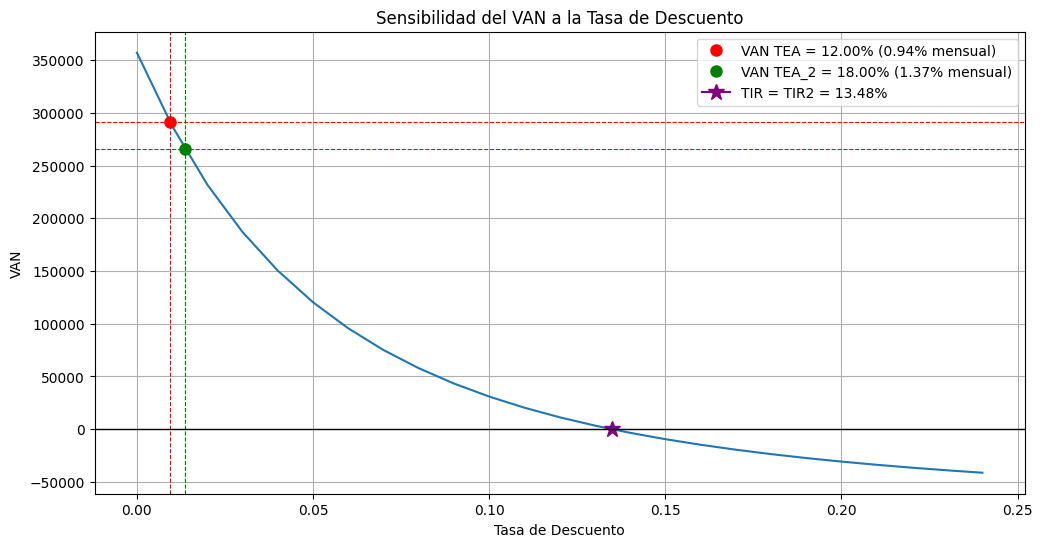

In [784]:
# Gráfico comparativo de ambos escenarios

# Definimos rango de tasas de descuento
tasas_rango = np.arange(0, 0.25, 0.01)

# Calculamos VAN para cada tasa
van_proyecto_rango = [nf.npv(tasa, nuevo_cash_flow) for tasa in tasas_rango]

# Creo el grafico
plt.figure(figsize=(12, 6))
plt.plot(tasas_rango, van_proyecto_rango, linestyle='-')

# Marcar VAN
plt.plot(r, van, 'ro', markersize=8, label=f'VAN TEA = {TEA*100:.2f}% ({r*100:.2f}% mensual)')
plt.axvline(r, color='red', linestyle='--', linewidth=0.8)
plt.axhline(van, color='red', linestyle='--', linewidth=0.8)
plt.plot(r2, van2, 'go', markersize=8, label=f'VAN TEA_2 = {TEA_2*100:.2f}% ({r2*100:.2f}% mensual)')
plt.axvline(r2, color='green', linestyle='--', linewidth=0.8)
plt.axhline(van2, color='green', linestyle='--', linewidth=0.8)

# Marcar TIR
plt.plot(tir, 0, color='purple', markersize=12, marker='*', label=f'TIR = TIR2 = {tir:.2%}') # Mostrar la TIR

plt.title('Sensibilidad del VAN a la Tasa de Descuento')
plt.xlabel('Tasa de Descuento')
plt.ylabel('VAN')


plt.grid(True)
plt.axhline(0, color='black', linestyle='-', linewidth=1)
plt.legend()
plt.show()

In [785]:
print('''
Interpretación del Gráfico de Sensibilidad del VAN a la Tasa de Descuento:

El gráfico ilustra cómo el VAN del proyecto disminuye a medida que aumenta la tasa de descuento.
A medida que la tasa de descuento se incrementa, el valor presente de los flujos de caja futuros
disminuye, lo que reduce el VAN. El punto donde la curva cruza el eje horizontal (VAN=0)
corresponde a la TIR del proyecto, que permanece constante independientemente del costo de capital.

El cambio en la tasa de descuento de {TEA*100:.4f}% anual a {TEA_2*100:.4f}% anual no afecta la factibilidad
del proyecto, ya que ambas tasas se encuentran por debajo de la TIR. Por lo tanto, la recomendación
es continuar con la inversión en el proyecto.
''')


Interpretación del Gráfico de Sensibilidad del VAN a la Tasa de Descuento:

El gráfico ilustra cómo el VAN del proyecto disminuye a medida que aumenta la tasa de descuento.
A medida que la tasa de descuento se incrementa, el valor presente de los flujos de caja futuros
disminuye, lo que reduce el VAN. El punto donde la curva cruza el eje horizontal (VAN=0)
corresponde a la TIR del proyecto, que permanece constante independientemente del costo de capital.

El cambio en la tasa de descuento de {TEA*100:.4f}% anual a {TEA_2*100:.4f}% anual no afecta la factibilidad
del proyecto, ya que ambas tasas se encuentran por debajo de la TIR. Por lo tanto, la recomendación
es continuar con la inversión en el proyecto.

